In [2]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict

from torch.autograd import Variable
from torchinfo import summary

import multiprocessing as mp

print(torchvision.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device())

0.10.0+cu111
1.9.0+cu111
True
0


### Test middle features of the 1st stage model

In [5]:
softmax_layer = nn.Softmax(dim=0)
sigmoid_layer = nn.Sigmoid()

In [6]:
a = [5,2,1]
input = torch.FloatTensor(a)
softmax_output = softmax_layer(input)
sigmoid_output = sigmoid_layer(input)

In [7]:
print(f"input: {input.tolist()}")
print(f"soft max output: {softmax_output.tolist()}")
print(f"sigmoid output: {sigmoid_output.tolist()}")

input: [5.0, 2.0, 1.0]
soft max output: [0.9362395405769348, 0.04661262035369873, 0.01714782603085041]
sigmoid output: [0.9933071732521057, 0.8807970285415649, 0.7310585975646973]


In [9]:
from models import RES_LSTM

model_loc = "D:/eat_detection/results/1/model_RES_LSTM_30_16_8_v4/"

print("load the best model for testing")
sys.stdout.flush()
model = RES_LSTM(seq_len=16).cuda()
model = torch.nn.DataParallel(model).cuda()
try:
    checkpoint = torch.load(os.path.join(model_loc, f"checkpoint_best.tar"))
except:
    print("no 'checkpoint_best.tar' is found")
    exit(0)
model.load_state_dict(checkpoint['model_state_dict'])

load the best model for testing


<All keys matched successfully>

In [10]:
summary(model, input_size=(32,16, 3, 128, 128))  

D:\Anaconda3\envs\torch-1.9\lib\site-packages\torch\nn\functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ..\c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Layer (type:depth-idx)                                  Output Shape              Param #
DataParallel                                            --                        --
├─RES_LSTM: 1-1                                         [32, 16, 3]               --
│    └─Spatial_Encoder: 2-1                             [32, 16, 512, 1, 1]       --
│    │    └─Sequential: 3-1                             [512, 512, 1, 1]          21,284,672
│    └─Flatten: 2-2                                     [32, 16, 512]             --
│    └─BatchNorm1d: 2-3                                 [32, 16, 512]             32
│    └─LSTM: 2-4                                        [32, 16, 128]             460,800
│    └─Dropout: 2-5                                     [32, 16, 128]             --
│    └─Sequential: 2-6                                  [32, 16, 3]               --
│    │    └─Linear: 3-2                                 [32, 16, 3]               387
│    │    └─ReLU: 3-3                         

In [11]:
data_path = "D:/eat_detection/VideoData_independent/test_set/p016_c1/"
f = open(os.path.join(data_path,"gt_frame_3labels.txt"),"r")
gt_frame = [str.split(line, "\t") for line in f.readlines()]

preprocess = transforms.Compose([
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
    
sample = []
count = 0
for frame_info in gt_frame[0:16]:
    frame_loc = os.path.join(data_path,frame_info[0])
    sample.append(Image.open(frame_loc).convert('RGB'))

sample = torch.stack([transforms.functional.to_tensor(frame) for frame in sample])
sample = preprocess(sample)
sample = torch.unsqueeze(sample, 0)

In [12]:
sample.size()

torch.Size([1, 16, 3, 224, 224])

In [13]:
output,output_2 = model(sample)

In [14]:
output_2

tensor([[[ 0.0000,  2.2702,  2.7893],
         [ 0.0000,  4.0673,  4.0746],
         [ 0.0000,  3.7475,  5.6147],
         [ 0.0000,  2.3581,  8.9268],
         [ 0.0000,  1.0783,  9.0015],
         [ 0.0000,  0.3275,  8.9307],
         [ 0.0000,  0.0000, 11.6178],
         [ 0.0000,  0.0000,  9.7797],
         [ 0.0000,  0.0000, 10.9554],
         [ 0.5395,  0.0000, 10.3798],
         [ 0.0000,  0.1170, 11.9309],
         [ 7.3772,  0.0000,  4.2686],
         [ 7.2203,  0.0000,  0.0000],
         [ 8.2468,  0.0000,  0.4476],
         [12.2051,  0.0000,  0.2572],
         [10.5540,  0.0000,  0.2996]]], device='cuda:0',
       grad_fn=<ReluBackward0>)

In [17]:
softmax_layer = nn.Softmax(dim=1)
sigmoid_layer = nn.Sigmoid()

In [43]:
input = output_2.squeeze()
softmax_output = softmax_layer(input).squeeze().tolist()
sigmoid_output = sigmoid_layer(input).squeeze().tolist()
input = input.tolist()
for idx in range(16):
    message = f"input: {input[idx][0]:>0.4f} {input[idx][1]:>0.4f} {input[idx][2]:>0.4f}\t\
            softmax: {softmax_output[idx][0]:>0.4f} {softmax_output[idx][1]:>0.4f} {softmax_output[idx][2]:>0.4f}\t\
            sigmoid: {sigmoid_output[idx][0]:>0.4f} {sigmoid_output[idx][1]:>0.4f} {sigmoid_output[idx][2]:>0.4f}"
    print(message)

input: 0.0000 2.2702 2.7893	            softmax: 0.0371 0.3592 0.6037	            sigmoid: 0.5000 0.9064 0.9421
input: 0.0000 4.0673 4.0746	            softmax: 0.0085 0.4940 0.4976	            sigmoid: 0.5000 0.9832 0.9833
input: 0.0000 3.7475 5.6147	            softmax: 0.0031 0.1334 0.8634	            sigmoid: 0.5000 0.9770 0.9964
input: 0.0000 2.3581 8.9268	            softmax: 0.0001 0.0014 0.9985	            sigmoid: 0.5000 0.9136 0.9999
input: 0.0000 1.0783 9.0015	            softmax: 0.0001 0.0004 0.9995	            sigmoid: 0.5000 0.7462 0.9999
input: 0.0000 0.3275 8.9307	            softmax: 0.0001 0.0002 0.9997	            sigmoid: 0.5000 0.5812 0.9999
input: 0.0000 0.0000 11.6178	            softmax: 0.0000 0.0000 1.0000	            sigmoid: 0.5000 0.5000 1.0000
input: 0.0000 0.0000 9.7797	            softmax: 0.0001 0.0001 0.9999	            sigmoid: 0.5000 0.5000 0.9999
input: 0.0000 0.0000 10.9554	            softmax: 0.0000 0.0000 1.0000	            sigmoid: 0.5000 0.50

In [41]:
input[idx]

[0.0, 2.270198106765747, 2.7892556190490723]

### Test 2nd stage dataset class

In [ ]:
class probabilityDataset(data.Dataset):
    def __init__(self,
                  data_loc,
                  gt_loc,
                  mode="train",
                  label_type="all",
                  run_times=10,
                  raw_seq_len=16,
                  raw_stride=1,
                  downsample_rate=4,
                  raw_sample_len=20000):
        'Initialization'
        self.finish_initialize = False
        sample_list = []
        label_list = []
        read_samples_args = []
        self.label_type = label_type
        self.raw_seq_len = raw_seq_len
        self.raw_sample_len = raw_sample_len
        self.downsample_rate = downsample_rate
        self.raw_stride = raw_stride
        for model_idx in range(1,11):
            prob_loc = os.path.join(data_loc,f"{model_idx}/result_RES_LSTM_30_16_8_v4_{mode}/frame_features/")
            read_samples_args.append([prob_loc,gt_loc])
        pool = mp.Pool(20)
        ret = pool.map(self.read_raw_samples,read_samples_args)

        for data in ret:
            sample_list.append(data[0])
            label_list.append(data[1])
        self.sample_list = np.concatenate(sample_list)
        self.label_list = np.concatenate(label_list)
        
        pool.close()  
        pool.join() 
    
        # Standardization         
        self.sample_list[self.label_list!=-1] = (self.sample_list[self.label_list!=-1]-MEAN)/STD
        self.finish_initialize = True
        
    def __len__(self):
        return len(self.label_list)
    
    def __getitem__(self, idx):
        return self.sample_list[idx],self.label_list[idx]
    
    def read_raw_samples(self, args):
        sample_loc,gt_loc = args[0], args[1]
        video_list = ["_".join(f.split(".")[0].split("_")[1:3]) for f in os.listdir(sample_loc)]
        #video_list = ["p072_c1"]
        samples = []
        labels = []
        count = 0
        for video_idx in video_list:
            cur_samples,cur_labels = self.read_prob(sample_loc, gt_loc, video_idx)
            samples.append(cur_samples[:,::self.downsample_rate,:])
            labels.append(cur_labels[:,::self.downsample_rate])
            #count += 1
            #if count > 4:
            #    break
        return np.concatenate(samples), np.concatenate(labels)
  
    def read_prob(self, prob_loc, gt_loc, video_idx):
        f_prob = open(os.path.join(prob_loc,f"features_{video_idx}.txt"),"r")
        f_gt = open(os.path.join(gt_loc,video_idx,"gt_frame_3labels.txt"),"r")
        # default sample value is 0, and default label is -1( will be ingored when computing loss)
        samples = np.zeros((self.raw_seq_len,self.raw_sample_len,3)) 
        labels = np.ones((self.raw_seq_len,self.raw_sample_len)) * (-1)
        for col_idx, line in enumerate(f_prob.readlines()):
            seq_features = line.split("\n")[0].split("\t")[1:]
            for row_idx in range(0,len(seq_features),3):
                position_idx = row_idx // 3  # the frame index in the current sequence
                frame_idx = col_idx * self.raw_stride + position_idx  # the frame index in the current frame list
                samples[position_idx,frame_idx,0:3] = seq_features[row_idx:row_idx+3]
        frame_gt = np.array([LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in f_gt.readlines()])
        if self.label_type in ["bite","drink"]:
            frame_gt = (frame_gt==LABEL_TABLE[self.label_type]).astype("int")
        for idx in range(0,self.raw_seq_len):
            labels[idx,idx:idx+len(frame_gt)-self.raw_seq_len+1] = frame_gt[idx:idx+len(frame_gt)-self.raw_seq_len+1]
        f_prob.close()
        f_gt.close()
        return samples.astype("float"),labels.astype("int")

In [ ]:
from constants import LABEL_TABLE
raw_sample_len = 20000
downsample_rate = 4
raw_seq_len = 16
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
MEAN = [1.80444053, 0.80193992, 11.10639638]
STD = [4.21282851, 3.02531022, 5.59236825]
train_set = probabilityDataset(
                    data_loc = "/scratch1/zeyut/eat_detection/results/",
                    gt_loc = "/scratch1/zeyut/eat_detection/all_labels/",
                    mode = "train",
                    run_times = 10,
                    raw_seq_len = raw_seq_len,
                    downsample_rate = downsample_rate,
                    raw_sample_len = raw_sample_len
                    )

In [ ]:
train_set.sample_list.shape

In [ ]:
aver = train_set.sample_list[train_set.label_list!=-1].mean(axis=0)
std = train_set.sample_list[train_set.label_list!=-1].std(axis=0)
print(f"train set mean: {aver}")
print(f"train set std: {std}")

In [ ]:
z = train_set.sample_list
z[train_set.label_list!=-1] = (train_set.sample_list[train_set.label_list!=-1] - aver)/std

In [ ]:
z.shape

In [ ]:
train_set.sample_list[0][4990:5000]

In [ ]:
z[0][4990:5000]

### Visualize model details

In [ ]:
class single_LSTM(nn.Module):
    def __init__(self,seq_len=10000):
        super(single_LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=3,
                            hidden_size=64,
                            num_layers=1,
                            batch_first=True)
        self.batch_norm = nn.BatchNorm1d(affine=False,
                                         num_features=int(seq_len))
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Sequential(nn.Linear(64, LABEL_NUM),
                                nn.ReLU())        
        self.act = nn.Softmax(dim=-1)
            
        '''initialization'''                          
        for name, param in self.lstm.named_parameters():
            if 'bias' in name:
                 nn.init.constant_(param, 0.0)
            elif 'weight_ih' in name:
                 nn.init.kaiming_normal_(param)
            elif 'weight_hh' in name:
                 nn.init.orthogonal_(param)
        for name, param in self.fc.named_parameters():
            if 'weight' in name:
                nn.init.kaiming_normal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)   

    def forward(self, x):
        x,_ = self.lstm(x)
        x = self.batch_norm(x)
        x = self.dropout(x)
        x = self.fc(x)
        output = self.act(x)
        return output

In [ ]:
LABEL_NUM=3
model = single_LSTM().cuda()
summary(model, input_size=(32,10000,3))

In [3]:
import matplotlib.pyplot as plt

def read_prob(prob_loc, gt_loc, video_idx):
    f_prob = open(os.path.join(prob_loc,f"features_{video_idx}.txt"),"r")
    f_gt = open(os.path.join(gt_loc,video_idx,"gt_frame_3labels.txt"),"r")
    # default sample value is 0, and default label is -1( will be ingored when computing loss)
    samples = np.ones((raw_seq_len,raw_sample_len,3)) * (-1)
    labels = np.ones((raw_seq_len,raw_sample_len)) * (-1)
    for col_idx, line in enumerate(f_prob.readlines()):
        seq_probs = line.split("\n")[0].split("\t")[1:]
        for row_idx in range(0,len(seq_probs),3):
            position_idx = row_idx // 3  # the frame index in the current sequence
            frame_idx = col_idx * raw_stride + position_idx  # the frame index in the current frame list
            samples[position_idx,frame_idx,0:3] = seq_probs[row_idx:row_idx+3]
    frame_gt = [LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in f_gt.readlines()]
    for idx in range(0,raw_seq_len):
        labels[idx,idx:idx+len(frame_gt)-raw_seq_len+1] = frame_gt[idx:idx+len(frame_gt)-raw_seq_len+1]
    f_prob.close()
    f_gt.close()
    return samples.astype("float"),labels.astype("int")
    
def read_raw_samples(prob_loc,gt_loc):
    sample_list = []
    label_list = []
    #video_list = [f[6:13] for f in os.listdir(prob_loc)]
    #video_list = ["p020_c1"] #from train set
    #video_list = ["p072_c1"] #from test set
    video_list = ["p024_c2"] #from validation set
    for video_idx in video_list:
        cur_samples,cur_labels = read_prob(prob_loc, gt_loc, video_idx)
        sample_list.append(cur_samples)
        label_list.append(cur_labels)
    samples = np.concatenate(sample_list)
    labels = np.concatenate(label_list)
    return samples, labels

result_loc = "D:/eat_detection/results/"
gt_loc = "D:/OneDrive/PhD/work/eat_detection/CafeteriaData/all_labels/"
raw_stride = 1
raw_seq_len = 16
raw_sample_len = 10000
stratified_samples = [[] for i in range(raw_seq_len)]
for model_idx in range(1,4):
    prob_loc = f"{result_loc}{model_idx}/result_RES_LSTM_30_16_8_v4_test/frame_probs/"
    samples, labels = read_raw_samples(prob_loc,gt_loc)
    for position_idx in range(seq_len):
        stratified_samples[position_idx].append(samples[position_idx])
stratified_samples = np.array(stratified_samples)    

sample_max = np.max(stratified_samples,axis = 1)
sample_min = np.min(stratified_samples,axis = 1)

In [7]:
#result_loc = "/scratch1/zeyut/eat_detection/results/"
#gt_loc = "/scratch1/zeyut/eat_detection/all_labels/"
result_loc = "D:/eat_detection/results_10runs/"
gt_loc = "D:/OneDrive/PhD/work/eat_detection/CafeteriaData/all_labels/"
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
raw_stride = 1
raw_seq_len = 16
raw_sample_len = 10000
stratified_samples = [[] for i in range(raw_seq_len)]
stratified_labels = [[] for i in range(raw_seq_len)]

for model_idx in range(1,4):
    prob_loc = f"{result_loc}{model_idx}/result_RES_LSTM_30_16_8_v4_val/frame_features/"
    samples, labels = read_raw_samples(prob_loc,gt_loc)
    for position_idx in range(raw_seq_len):
        stratified_samples[position_idx].append(samples[position_idx])
        stratified_labels[position_idx].append(labels[position_idx])
stratified_samples = np.array(stratified_samples)    
stratified_labels = np.array(stratified_labels)    

sample_max = np.max(stratified_samples,axis = 1)
sample_min = np.min(stratified_samples,axis = 1)

In [8]:
stratified_samples[7,0,stratified_samples[7,0,:,0]>=0].shape

(4621, 3)

In [9]:
stratified_labels.shape

(16, 3, 10000)

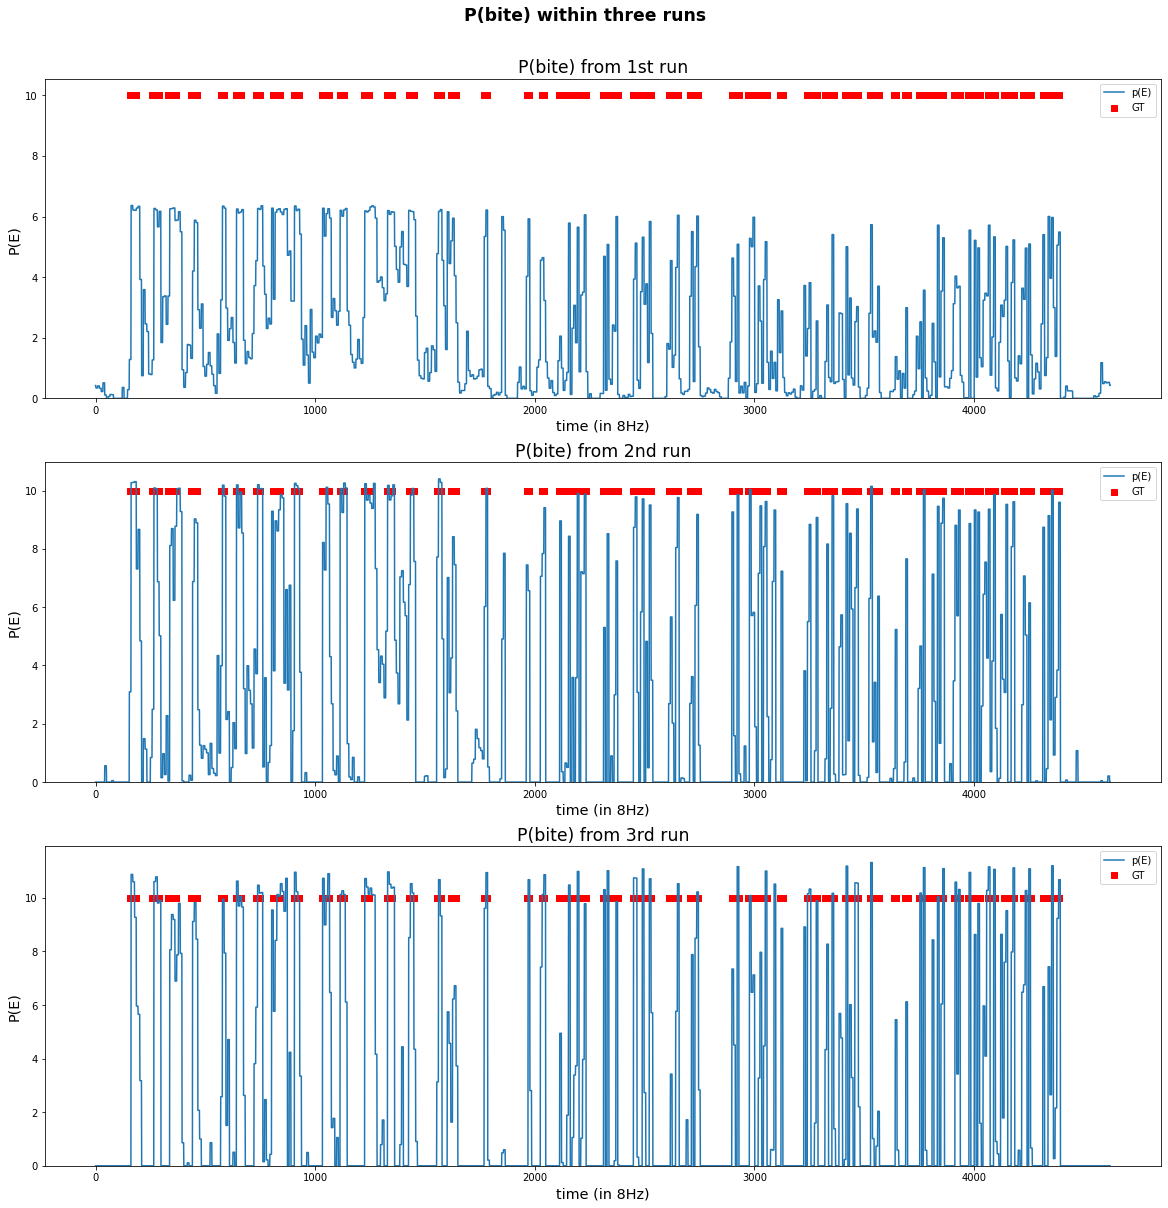

In [12]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(bite) within three runs",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("P(bite) from 1st run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("P(bite) from 2nd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,1,stratified_samples[0,1,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,1,stratified_labels[0,1,:]>=0])),
            (stratified_labels[0,1,stratified_labels[0,1,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("P(bite) from 3rd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,2,stratified_samples[0,2,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,2,stratified_labels[0,2,:]>=0])),
            (stratified_labels[0,2,stratified_labels[0,2,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./bite_1st_frame.jpg")

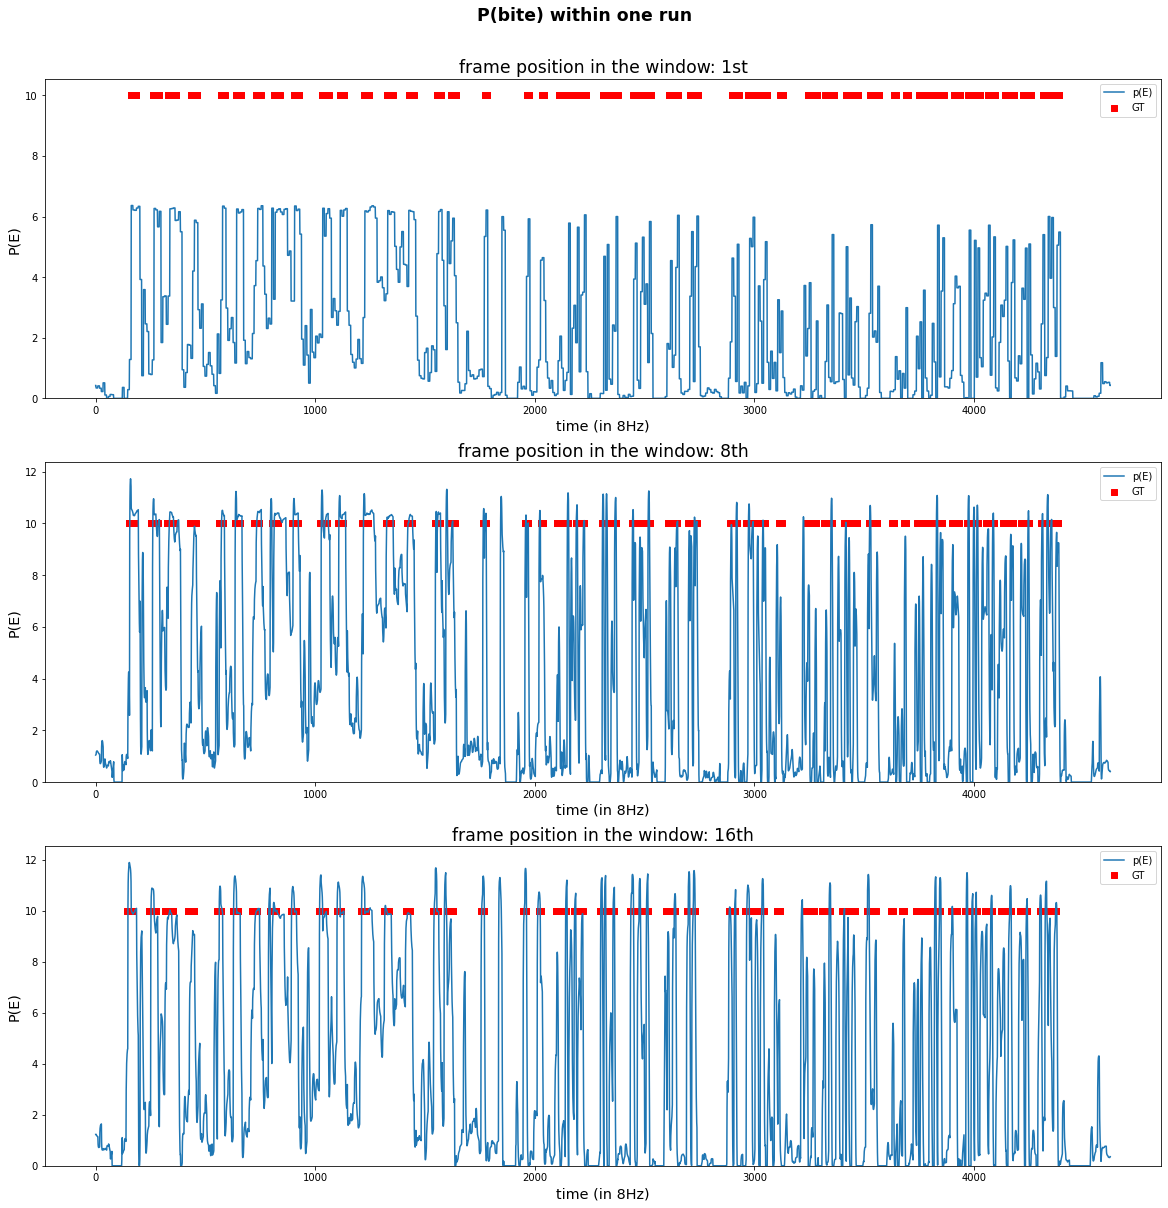

In [14]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(bite) within one run",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("frame position in the window: 1st",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("frame position in the window: 8th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[7,0,stratified_samples[7,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[7,0,stratified_labels[7,0,:]>=0])),
            (stratified_labels[7,0,stratified_labels[7,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("frame position in the window: 16th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[15,0,stratified_samples[15,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[15,0,stratified_labels[15,0,:]>=0])),
            (stratified_labels[15,0,stratified_labels[15,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./bite_one_run.jpg")

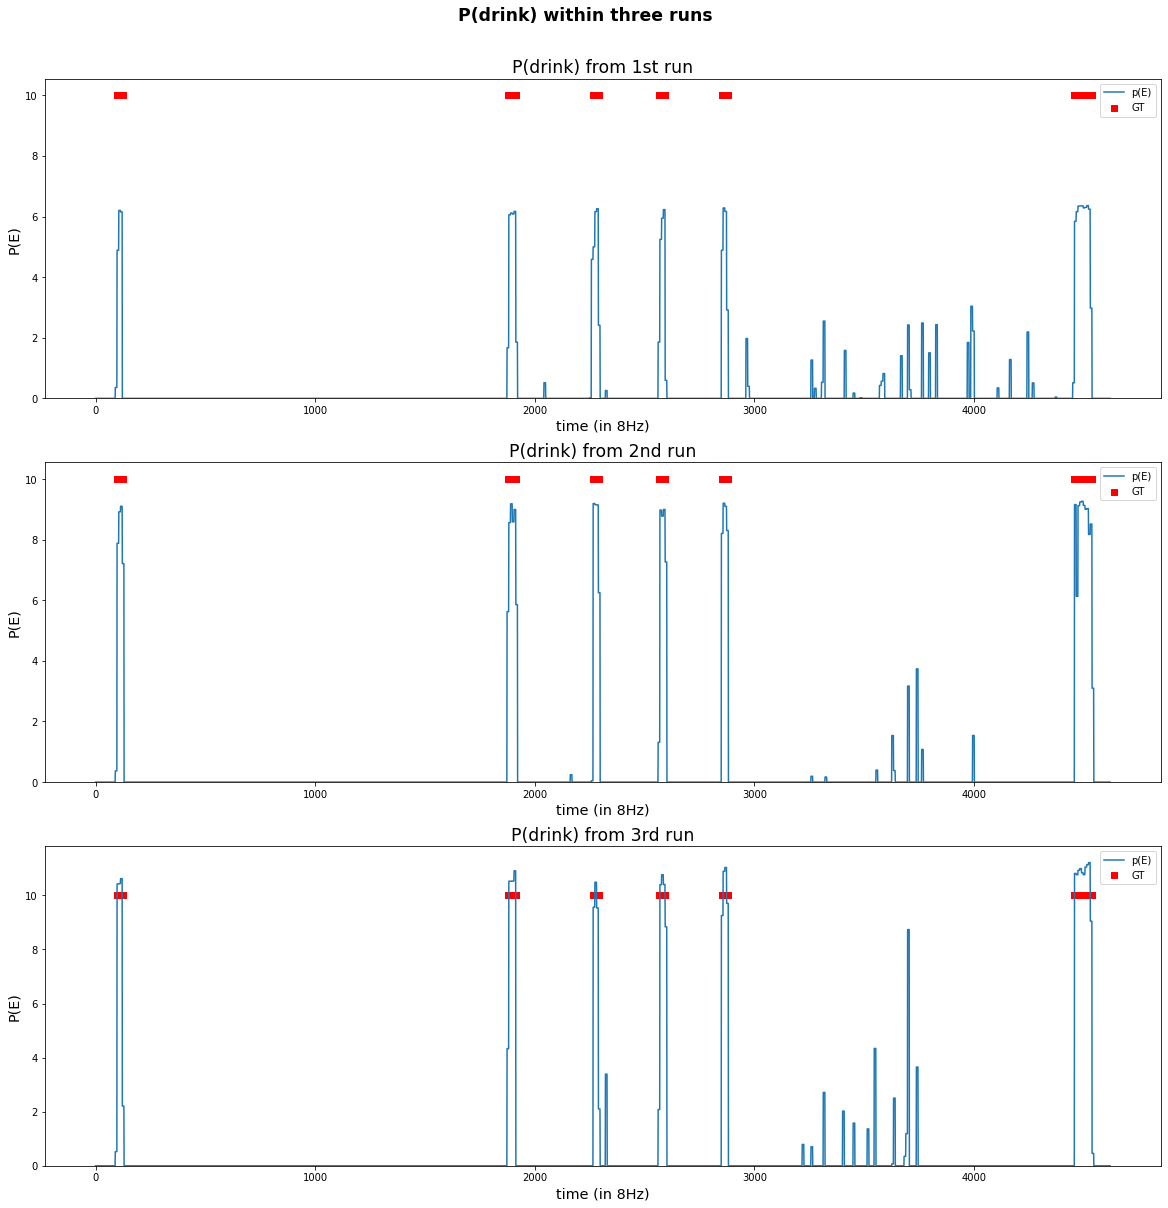

In [16]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(drink) within three runs",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("P(drink) from 1st run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,1]>=0,1])
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("P(drink) from 2nd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,1,stratified_samples[0,1,:,1]>=0,1])
plt.scatter(np.arange(len(stratified_labels[0,1,stratified_labels[0,1,:]>=0])),
            (stratified_labels[0,1,stratified_labels[0,1,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("P(drink) from 3rd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,2,stratified_samples[0,2,:,1]>=0,1])
plt.scatter(np.arange(len(stratified_labels[0,2,stratified_labels[0,2,:]>=0])),
            (stratified_labels[0,2,stratified_labels[0,2,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./drink_1st_frame.jpg")

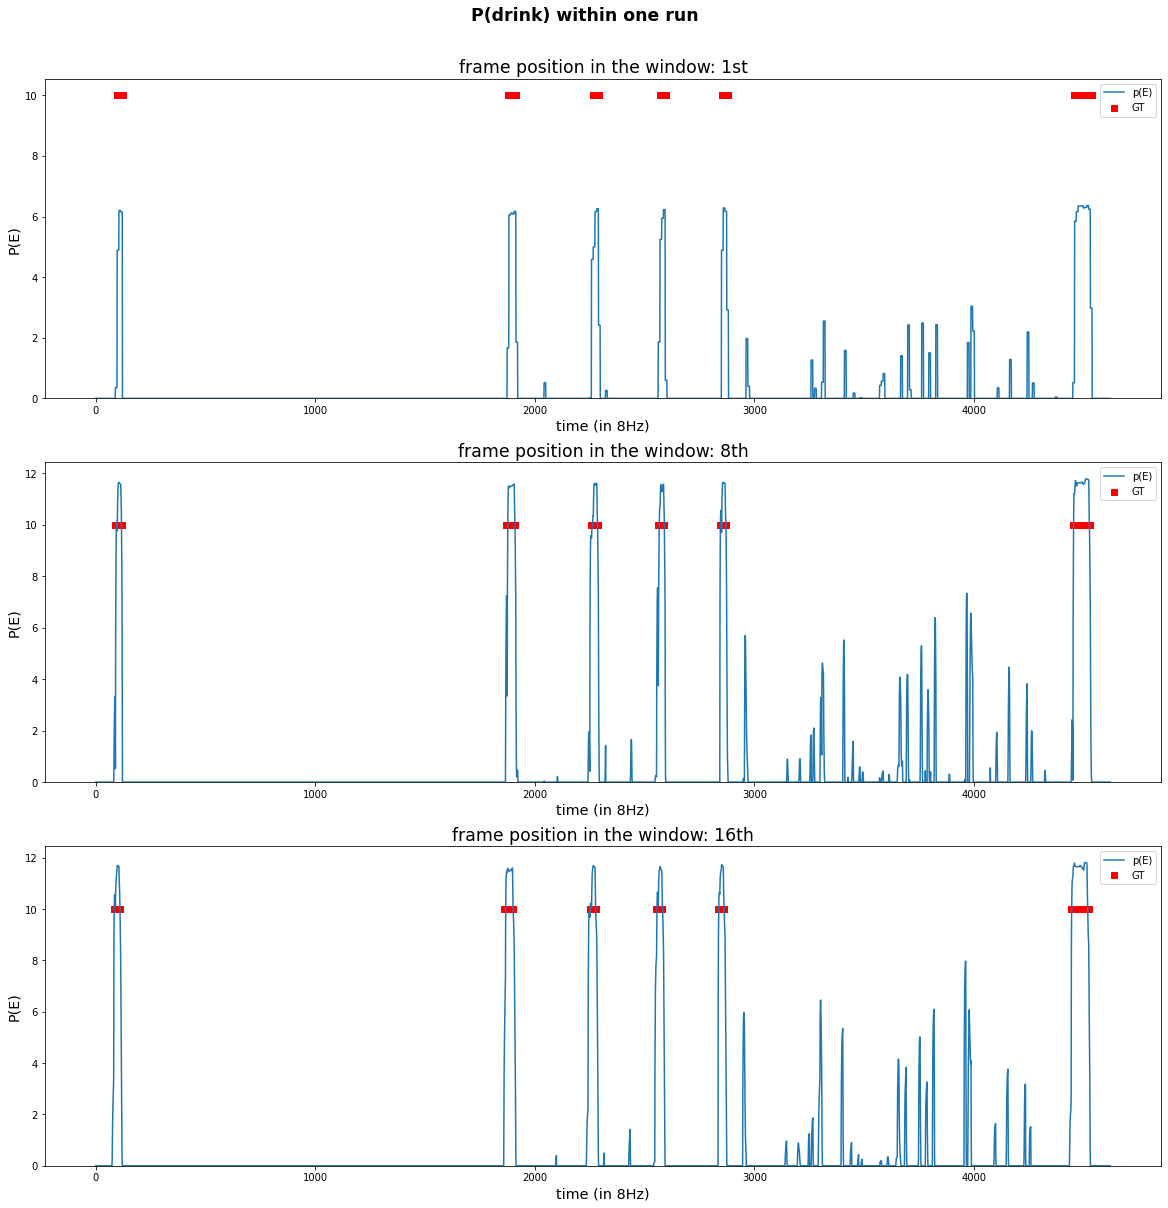

In [17]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(drink) within one run",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("frame position in the window: 1st",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("frame position in the window: 8th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[7,0,stratified_samples[7,0,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(stratified_labels[7,0,stratified_labels[7,0,:]>=0])),
            (stratified_labels[7,0,stratified_labels[7,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("frame position in the window: 16th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[15,0,stratified_samples[15,0,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(stratified_labels[15,0,stratified_labels[15,0,:]>=0])),
            (stratified_labels[15,0,stratified_labels[15,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./drink_one_run.jpg")